## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

## Constants + Fixing output fonts

In [2]:
# Set Times New Roman font and handle negative sign display issues
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# Constants definition
sigma = 5.670374419e-8  # Stefan-Boltzmann constant, W·m⁻²·K⁻⁴
G_sc = 1353  # Solar constant, W/m²
H = 8500  # Scale height, unit: m

## Plot

In [3]:
# Change this percentage value as needed
density_cutoff_percent = 20  # This means show density from 0 to 20% of the maximum density value

# Station altitude data (unit: m)
station_altitudes = {
    'BON': 213,
    'DRA': 1007,
    'FPK': 634,  # FPK corresponds to FRK in the paper
    'GWN': 98,
    'PSU': 376,
    'SXF': 473,
    'TBL': 1689
}

# Fitting parameters for each station, used for the function CF = c1 * k_d^(c2)
station_params = {
    'BON': (0.607,1.744),#(0.625, 1.913),
    'DRA': (0.323,0.977),#(0.348, 1.230),
    'FPK': (0.580,1.505),#(0.593, 1.531),
    'GWN': (0.580,1.505),#(0.610, 1.622),
    'PSU': (0.625,1.651),#(0.656, 2.054),
    'SXF': (0.623,1.591),#(0.661, 1.893),
    'TBL': (0.500,1.508)#(0.531, 1.819)
}

# Overall fitting parameters
overall_c1 = 0.608 #0.585 
overall_c2 = 1.865 #1.748

# Data file paths
precipitation_h5_path = r'/Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/all_precipitation_data.h5'
file_path = r'/Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/output.h5'
stations = ['BON', 'DRA', 'FPK', 'GWN', 'PSU', 'SXF', 'TBL']

# List to store processed DataFrames for each station, used for plotting overall scatter plot later
data_list = []

# Read precipitation data
with pd.HDFStore(precipitation_h5_path, 'r') as precip_store:
    precipitation_data = {
        station: precip_store[station].set_index('datetime')['PRECIPITATIONCAL']
        for station in stations
    }

# Define output image save directory
output_dir = r'/Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define data processing function for each station
def process_station_data(station):
    with pd.HDFStore(file_path, 'r') as h5_file:
        dataset = h5_file[station].copy()
    dataset.index = pd.to_datetime(dataset.index)

    # For DRA station, delete data from 2017 to 2023
    if station == 'DRA':
        dataset = dataset[~((dataset.index.year >= 2017) & (dataset.index.year <= 2023))]
    dataset = dataset[~(dataset.index.year == 2023)]

    # Align precipitation data: only keep dates with daily average precipitation of 0
    precip_data = precipitation_data[station]
    daily_precip = precip_data.groupby(precip_data.index.date).mean()
    valid_dates = daily_precip[daily_precip == 0].index
    valid_dates_index = pd.Index(valid_dates)
    dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]

    # Calculate G_on (solar constant)
    day_of_year = dataset.index.dayofyear
    B = (day_of_year - 1) * 360 / 365
    G_on = G_sc * (1.000110 + 0.034221 * np.cos(np.radians(B)) +
                   0.001280 * np.sin(np.radians(B)) +
                   0.000719 * np.cos(2 * np.radians(B)) +
                   0.000077 * np.sin(2 * np.radians(B)))

    # Filtering conditions
    condition_1 = (dataset['sza'] < 72.5) & (dataset['ghi_m'] > 0) & (dataset['dhi_m'] > 0) & (
                dataset['ghi_m'] / dataset['ghi_c'] < 1.5)
    condition_2 = dataset.index.time >= pd.to_datetime("08:00").time()
    condition_4 = dataset['ghi_m'] < (1.2 * G_on * np.cos(np.radians(dataset['sza'])) ** 1.2 + 50)
    condition_6 = dataset['dni_m'] < (0.95 * G_on * np.cos(np.radians(dataset['sza'])) ** 0.2 + 10)
    condition_8 = ((dataset['dhi_m'] / dataset['ghi_m']) <= 1)
    condition_9 = ((dataset['ghi_m'] / dataset['ghi_c']) > 0.1)
    dataset = dataset[condition_1 & condition_2 & condition_4 & condition_6 & condition_8 & condition_9]

    # Calculate other parameters
    dataset['k_d'] = dataset['dhi_m'] / dataset['ghi_m']
    dataset['cos_theta_z'] = np.cos(np.radians(dataset['sza']))
    dataset['e_s'] = 6.112 * np.exp(17.625 * dataset['temp'] / (dataset['temp'] - 30.11 + 273.15))
    dataset['pw_hpa'] = dataset['e_s'] * dataset['rh'] / 100
    condition_3 = (dataset['pw_hpa'] >= 0) & (dataset['e_s'] >= 0) & (dataset['dlw'] > 0) & (dataset['temp'] <= 90) & (
                dataset['temp'] >= -80)
    condition_7 = (dataset['qc_direct_n'] == 0) & (dataset['qc_dwsolar'] == 0) & (dataset['qc_diffuse'] == 0) & (
                dataset['qc_dwir'] == 0) & (dataset['qc_temp'] == 0) & (dataset['qc_rh'] == 0) & (
                              dataset['qc_pressure'] == 0)
    dataset = dataset[condition_3 & condition_7]

    dataset['sqrt_pw'] = np.sqrt(dataset['pw_hpa'] / 1013.25)
    dataset['altitude'] = station_altitudes[station]

    # Calculate e_sky and e_clear_sky
    dataset['e_sky'] = dataset['dlw'] / (sigma * ((dataset['temp'] + 273.15) ** 4))
    dataset['e_clear_sky'] = 0.6 + 1.652 * dataset['sqrt_pw'] + 0.15 * (np.exp(-dataset['altitude'] / H) - 1)

    # Calculate actual CF value: (e_sky - e_clear_sky) / (1 - e_clear_sky)
    dataset['CF_actual'] = (dataset['e_sky'] - dataset['e_clear_sky']) / (1 - dataset['e_clear_sky'])

    # Filter data points with k_d < 1
    dataset = dataset[dataset['k_d'] <= 1]

    return dataset

# Process and plot data for each station (plot a density plot for each station, overlaying two function curves)
for station in stations:
    df_station = process_station_data(station)
    data_list.append(df_station)  # Save for subsequent overall plot

    # X-axis is k_d, Y-axis is actual CF value
    x_vals = df_station['k_d'].values
    y_vals = df_station['CF_actual'].values

    plt.figure(figsize=(8, 6))
    hb = plt.hexbin(x_vals, y_vals, gridsize=50, cmap='YlGnBu', mincnt=1)
    
    # Calculate cutoff based on the selected percentage
    density_max = hb.get_array().max()
    cutoff_value = (density_cutoff_percent / 100) * density_max
    plt.clim(0, cutoff_value)
    plt.colorbar(hb, label='Density')

    # X-axis range (from 0 to the maximum k_d value in the current data)
    x_range = np.linspace(0, 1, 2000)

    # 1. Plot station fitting curve: CF = c1 * k_d^(c2)
    c1, c2 = station_params[station]
    y_station_curve = c1 * (x_range ** c2)
    plt.plot(x_range, y_station_curve, color='magenta', lw=2,
             label=f'{station} fit: {c1:.3f} * $k_d$^{c2:.3f}')

    # 2. Plot overall fitting curve: CF = {overall_c1} * k_d^({overall_c2})
    y_overall_curve = overall_c1 * (x_range ** overall_c2)
    plt.plot(x_range, y_overall_curve, color='cyan', lw=2,
             label=f'Overall fit: {overall_c1:.3f} * $k_d$^{overall_c2:.3f}')

    # Modify axis labels, with y-axis using LaTeX format for the formula, and k_d displayed as k_d
    plt.xlabel(r'$k_d$', fontsize=12)
    plt.ylabel(r'$(\epsilon_{sky} - \epsilon_{\rm clear\ sky})/(1-\epsilon_{\rm clear\ sky})$', fontsize=12)
    plt.title(f'{station} - Density Plot of r vs $k_d$', fontsize=14)
    plt.legend(frameon=False, fontsize=10)

    # Save the current station plot
    output_file = os.path.join(output_dir, f'{station}_density_plot.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"{station} density plot saved to {output_file}")

# Plot overall density map (all data)
df_all = pd.concat(data_list)
df_all = df_all[df_all['k_d'] <= 1]
x_all = df_all['k_d'].values
y_all = df_all['CF_actual'].values

plt.figure(figsize=(8, 6))
hb_all = plt.hexbin(x_all, y_all, gridsize=50, cmap='YlGnBu', mincnt=1)
density_max_all = hb_all.get_array().max()
cutoff_value_all = (density_cutoff_percent / 100) * density_max_all
plt.clim(0, cutoff_value_all)
plt.colorbar(hb_all, label='Density')

x_range_all = np.linspace(0, 1, 2000)
y_overall_curve_all = overall_c1 * (x_range_all ** overall_c2)
plt.plot(x_range_all, y_overall_curve_all, color='cyan', lw=2,
         label=f'Overall fit: {overall_c1:.3f} * $k_d$^{overall_c2:.3f}')

plt.xlabel(r'$k_d$', fontsize=12)
plt.ylabel(r'$(\epsilon_{sky} - \epsilon_{\rm clear\ sky})/(1-\epsilon_{\rm clear\ sky})$', fontsize=12)
plt.title('All Stations', fontsize=14)
plt.legend(frameon=False, fontsize=10)

output_file_all = os.path.join(output_dir, 'AllStations_density_plot.png')
plt.savefig(output_file_all, dpi=300, bbox_inches='tight')
plt.close()
print(f"All stations density plot saved to {output_file_all}")

/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3263737048.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


BON density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/BON_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3263737048.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


DRA density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/DRA_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3263737048.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


...

PSU density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/PSU_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3263737048.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


SXF density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/SXF_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3263737048.py:66: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


TBL density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/TBL_density_plot.png
All stations density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/AllStations_density_plot.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
import os
os.environ['PATH'] = '/Library/TeX/texbin/latex' + os.environ['PATH']

# Set Times New Roman font and handle negative sign display issues
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['text.usetex'] = True
# Constants
G_sc = 1366.1  # Solar constant (W/m^2)
sigma = 5.67e-8  # Stefan-Boltzmann constant (W/m^2/K^4)
H = 8500  # Scale height of the atmosphere (m)

# Change this percentage value as needed
density_cutoff_percent = 10  # This means show density from 0 to 20% of the maximum density value

# Station altitude data (unit: m)
station_altitudes = {
    'BON': 213,
    'DRA': 1007,
    'FPK': 634,  # FPK corresponds to FRK in the paper
    'GWN': 98,
    'PSU': 376,
    'SXF': 473,
    'TBL': 1689
}

# Fitting parameters for each station, used for the function CF = c1 * k_d^(c2)
station_params = {
    'BON': (0.607,1.744),#(0.625, 1.913),
    'DRA': (0.323,0.977),#(0.348, 1.230),
    'FPK': (0.580,1.505),#(0.593, 1.531),
    'GWN': (0.580,1.505),#(0.610, 1.622),
    'PSU': (0.625,1.651),#(0.656, 2.054),
    'SXF': (0.623,1.591),#(0.661, 1.893),
    'TBL': (0.500,1.508)#(0.531, 1.819)
}

# Overall fitting parameters
overall_c1 = 0.608 #0.585 
overall_c2 = 1.865 #1.748

# Data file paths
precipitation_h5_path = r'/Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/all_precipitation_data.h5'
file_path = r'/Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/output.h5'
stations = ['BON', 'DRA', 'FPK', 'GWN', 'PSU', 'SXF', 'TBL']

# Read precipitation data
with pd.HDFStore(precipitation_h5_path, 'r') as precip_store:
    precipitation_data = {
        station: precip_store[station].set_index('datetime')['PRECIPITATIONCAL']
        for station in stations
    }

# Define output image save directory
output_dir = r'/Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define data processing function for each station
def process_station_data(station):
    with pd.HDFStore(file_path, 'r') as h5_file:
        dataset = h5_file[station].copy()
    dataset.index = pd.to_datetime(dataset.index)

    # For DRA station, delete data from 2017 to 2023
    if station == 'DRA':
        dataset = dataset[~((dataset.index.year >= 2017) & (dataset.index.year <= 2023))]
    dataset = dataset[~(dataset.index.year == 2023)]

    # Align precipitation data: only keep dates with daily average precipitation of 0
    precip_data = precipitation_data[station]
    daily_precip = precip_data.groupby(precip_data.index.date).mean()
    valid_dates = daily_precip[daily_precip == 0].index
    valid_dates_index = pd.Index(valid_dates)
    dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]

    # Calculate G_on (solar constant)
    day_of_year = dataset.index.dayofyear
    B = (day_of_year - 1) * 360 / 365
    G_on = G_sc * (1.000110 + 0.034221 * np.cos(np.radians(B)) +
                   0.001280 * np.sin(np.radians(B)) +
                   0.000719 * np.cos(2 * np.radians(B)) +
                   0.000077 * np.sin(2 * np.radians(B)))

    # Filtering conditions
    condition_1 = (dataset['sza'] < 72.5) & (dataset['ghi_m'] > 0) & (dataset['dhi_m'] > 0) & (
                dataset['ghi_m'] / dataset['ghi_c'] < 1.5) & (dataset['dni_m'] > 0)
    condition_2 = dataset.index.time >= pd.to_datetime("08:00").time()
    condition_4 = dataset['ghi_m'] < (1.2 * G_on * np.cos(np.radians(dataset['sza'])) ** 1.2 + 50)
    condition_6 = dataset['dni_m'] < (0.95 * G_on * np.cos(np.radians(dataset['sza'])) ** 0.2 + 10)
    condition_8 = ((dataset['dhi_m'] / dataset['ghi_m']) <= 1)
    condition_9 = ((dataset['ghi_m'] / dataset['ghi_c']) >= 0.1) & ((dataset['ghi_m'] / dataset['ghi_c']) <= 1.5)
    dataset = dataset[condition_1 & condition_2 & condition_4 & condition_6 & condition_8 & condition_9]

    # Calculate other parameters
    dataset['k_d'] = dataset['dhi_m'] / dataset['ghi_m']
    dataset['cos_theta_z'] = np.cos(np.radians(dataset['sza']))
    dataset['e_s'] = 6.112 * np.exp(17.625 * dataset['temp'] / (dataset['temp'] - 30.11 + 273.15))
    dataset['pw_hpa'] = dataset['e_s'] * dataset['rh'] / 100
    condition_3 = (dataset['pw_hpa'] >= 0) & (dataset['e_s'] >= 0) & (dataset['dlw'] > 0) & (dataset['temp'] <= 90) & (
                dataset['temp'] >= -80)
    condition_7 = (dataset['qc_direct_n'] == 0) & (dataset['qc_dwsolar'] == 0) & (dataset['qc_diffuse'] == 0) & (
                dataset['qc_dwir'] == 0) & (dataset['qc_temp'] == 0) & (dataset['qc_rh'] == 0) & (
                              dataset['qc_pressure'] == 0)
    dataset = dataset[condition_3 & condition_7]

    dataset['sqrt_pw'] = np.sqrt(dataset['pw_hpa'] / 1013.25)
    dataset['altitude'] = station_altitudes[station]

    # Calculate e_sky and e_clear_sky
    dataset['e_sky'] = dataset['dlw'] / (sigma * ((dataset['temp'] + 273.15) ** 4))
    dataset['e_clear_sky'] = 0.6 + 1.652 * dataset['sqrt_pw'] + 0.15 * (np.exp(-dataset['altitude'] / H) - 1)

    # Calculate actual CF value: (e_sky - e_clear_sky) / (1 - e_clear_sky)
    dataset['CF_actual'] = (dataset['e_sky'] - dataset['e_clear_sky']) / (1 - dataset['e_clear_sky'])
    dataset = dataset.replace([np.inf, -np.inf], np.nan).dropna()
    #Filter data points with r<=1
    dataset = dataset[(dataset['CF_actual'] <= 1)]
    # Filter data points with k_d < 1
    dataset = dataset[dataset['k_d'] <= 1]

    return dataset

# Function to process and plot data for each station
def process_and_plot_station(station, data_list, output_dir):
    df_station = process_station_data(station)
    data_list.append(df_station)

    x_vals = df_station['k_d'].values
    y_vals = df_station['CF_actual'].values
    plt.figure(figsize=(8, 6))
    
    # Use hexbin with logarithmic normalization
    hb = plt.hexbin(x_vals, y_vals, gridsize=50, cmap='viridis', mincnt=1, norm=LogNorm())
    
    # Set consistent colorbar range across all plots
    plt.clim(1e0, 1e4)  # Fixed range for better comparison
    
    # Configure colorbar
    cbar = plt.colorbar(hb, label='')
    cbar.ax.tick_params(labelsize=16)
    ticks = np.array([1e0, 1e1, 1e2, 1e3, 1e4])
    cbar.set_ticks(ticks)

    # X-axis range
    x_range = np.linspace(0, 1, 2000)

    # Station-specific curve
    c1, c2 = station_params[station]
    y_station_curve = c1 * (x_range ** c2)
    plt.plot(x_range, y_station_curve, color='cyan', lw=2,
             label=rf'$\rm \gamma_{{\tiny {station}}} = {c1:.3f}\,{{\it k}}_{{\rm d}}^{{{c2:.2f}}}$')

    # Overall curve
    y_overall_curve = overall_c1 * (x_range ** overall_c2)
    plt.plot(x_range, y_overall_curve, color='red', lw=2,
             label=rf'$\rm \gamma_{{\tiny all\,stations}} = {overall_c1:.3f}\,{{\it k}}_{{\rm d}}^{{{overall_c2:.2f}}}$')

    # Axis configuration
    plt.xlabel(r'$k_{\rm d}$', fontsize=18)
    plt.ylabel(r'${\rm \gamma} = \frac{\varepsilon_{\rm sky} - \varepsilon_{\rm clear\,sky}}{1 - \varepsilon_{\rm clear\,sky}}$', fontsize=18)
    plt.xticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1], fontsize=16)
    plt.yticks([-0.5,-0.25,0,0.25,0.5,0.75,1], fontsize=16)
    plt.ylim(-0.6,1.1)
    plt.title(f'{station}', fontsize=18)
    
    # Legend configuration
    plt.legend(frameon=False, fontsize=14, loc='upper left')

    plt.savefig(os.path.join(output_dir, f'{station}_density_plot.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"{station} density plot saved to {os.path.join(output_dir, f'{station}_density_plot.png')}")

# Process and plot data for each station
data_list = []
for station in stations:
    process_and_plot_station(station, data_list, output_dir)

# Plot overall density map (all data)
df_all = pd.concat(data_list)
df_all = df_all[df_all['k_d'] <= 1]
x_all = df_all['k_d'].values
y_all = df_all['CF_actual'].values

plt.figure(figsize=(8, 6))

# Use hexbin with logarithmic normalization for all stations plot
hb_all = plt.hexbin(x_all, y_all, gridsize=50, cmap='viridis', mincnt=1, norm=LogNorm())

# Calculate cutoff for all stations plot
density_values_all = hb_all.get_array()
sorted_densities_all = np.sort(density_values_all)
cutoff_index_all = int(len(sorted_densities_all) * (1 - density_cutoff_percent / 100))
vmin_all = sorted_densities_all[0]  # Minimum non-zero value
vmax_all = sorted_densities_all[cutoff_index_all]

plt.clim(vmin_all, 1e4)
cbar = plt.colorbar(hb_all, label='')
cbar.ax.tick_params(labelsize=16)
ticks = np.array([1e0, 1e1, 1e2, 1e3, 1e4])
cbar.set_ticks(ticks)
x_range_all = np.linspace(0, 1, 2000)
y_overall_curve_all = overall_c1 * (x_range_all ** overall_c2)
plt.plot(x_range_all, y_overall_curve_all, color='red', lw=2,
         label=rf'$\rm \gamma_{{\tiny all\,stations}} = {overall_c1:.3f}\,{{\it k}}_{{\rm d}}^{{{overall_c2:.2f}}}$')
plt.xlabel(r'$k_{\rm d}$', fontsize=18)
plt.ylabel(r'$ \rm \gamma = \frac{\varepsilon_{sky} - \varepsilon_{\rm clear\,sky}}{1 - \varepsilon_{\rm clear\,sky}}$', fontsize=18)
plt.xticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('All Stations', fontsize=18)
plt.legend(frameon=False, fontsize=18)
plt.yticks([-0.5,-0.25,0,0.25,0.5,0.75,1])
plt.ylim(-0.6,1.1)
plt.title('all stations', fontsize=18)
plt.legend(frameon=False, fontsize=14, loc='upper left')
plt.savefig(os.path.join(output_dir, 'AllStations_density_plot.png'), dpi=300, bbox_inches='tight')
plt.close()
print(f"All stations density plot saved to {os.path.join(output_dir, 'AllStations_density_plot.png')}")

/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3266149629.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


BON density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/BON_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3266149629.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


DRA density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/DRA_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3266149629.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


...

PSU density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/PSU_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3266149629.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


SXF density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/SXF_density_plot.png


/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_23677/3266149629.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]


TBL density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/TBL_density_plot.png
All stations density plot saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/AllStations_density_plot.png


## Stacked bar plot with kd buckets per station

/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_1196/1420824283.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]
/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_1196/1420824283.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  dataset = dataset[dataset.index.normalize().isin(valid_dates_index)]
/var/folders/8v/j9k9_w615x5dxs8km9fp3nmc0000gn/T/ipykernel_1196/1420824283.py:81: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprec

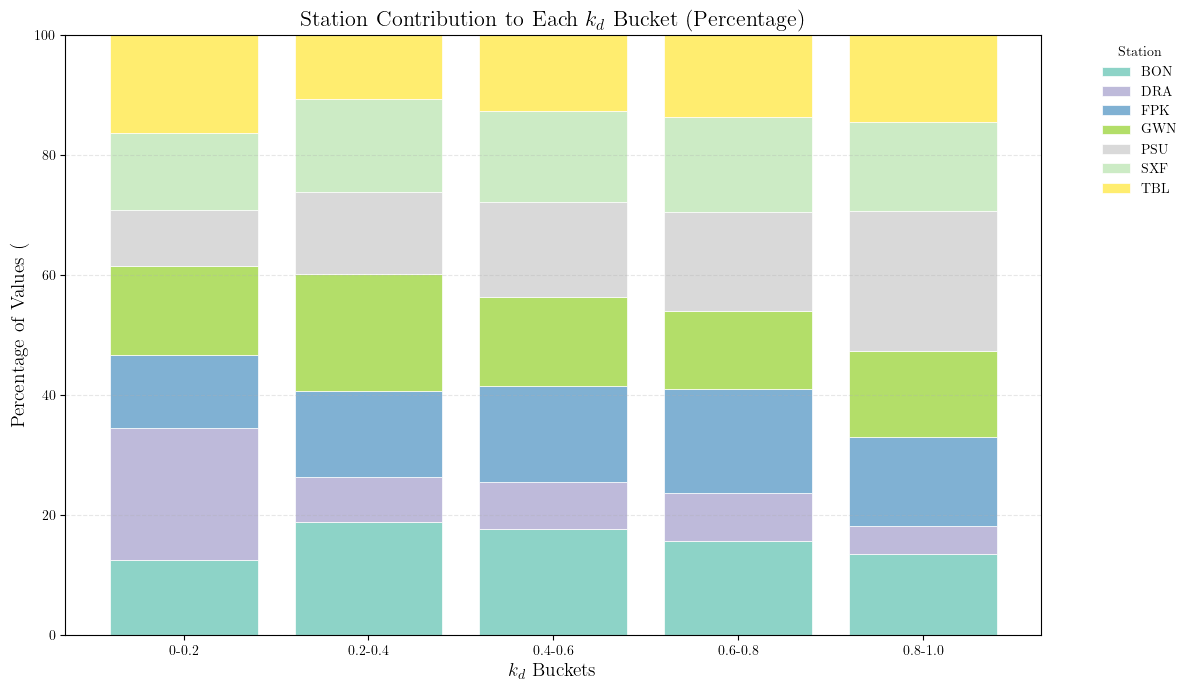

Percentage stacked bar chart saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/k_d_buckets_percentage_stacked.png


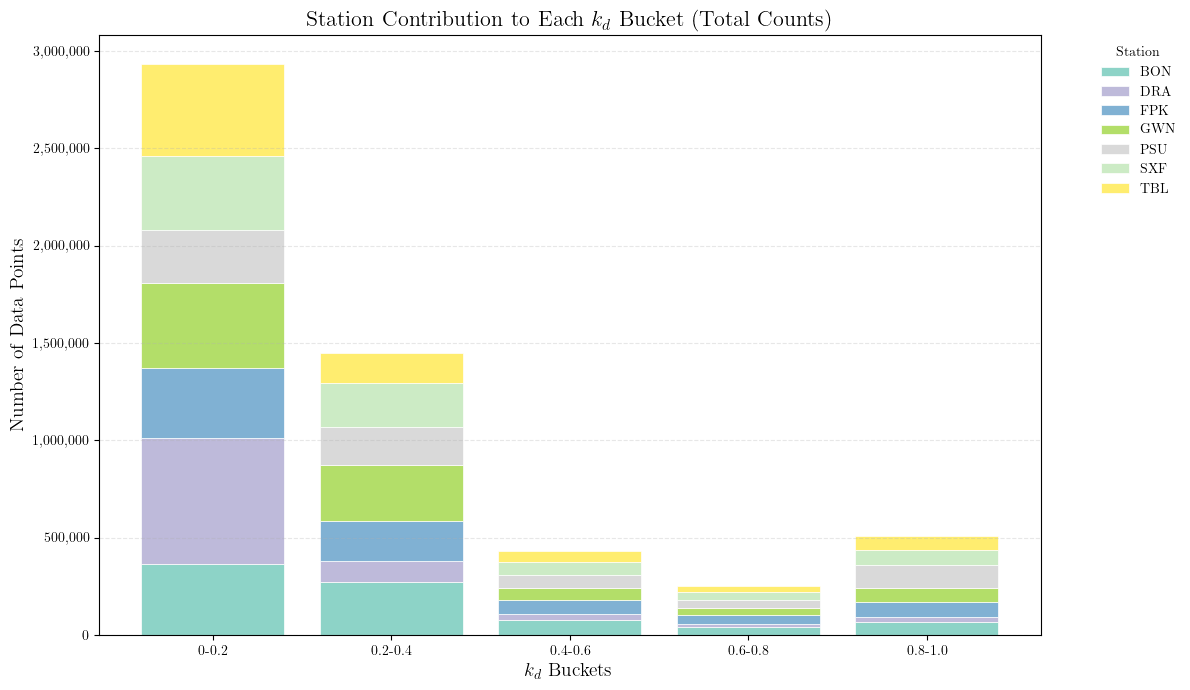

Counts stacked bar chart saved to /Users/akarsh1207/Desktop/Lab/Coimbra Research Group/Jiedong_work/scatter_plots/k_d_buckets_counts_stacked.png

SUMMARY: Data Points per k_d Bucket

Bucket       Total Points    Percentage  
------------------------------------------------------------
0-0.2        2,936,097        52.60%
0.2-0.4      1,448,879        25.95%
0.4-0.6      431,129           7.72%
0.6-0.8      254,273           4.55%
0.8-1.0      512,006           9.17%
------------------------------------------------------------
TOTAL        5,582,384       100.00%

Station Contribution to Each Bucket (in counts)
               BON     DRA     FPK     GWN     PSU     SXF     TBL
k_d_bucket                                                        
0-0.2       366795  644450  359698  436318  273682  377637  477517
0.2-0.4     273290  108619  206674  283971  197042  224918  154365
0.4-0.6      76559   33190   68883   64037   68537   65286   54637
0.6-0.8      39774   20272   44127   33260   41

In [ ]:
# Create stacked bar charts for k_d distribution by station

# Define k_d buckets
k_d_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
k_d_labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']

# Process data for all stations and categorize by k_d buckets
station_bucket_counts = {}
for station in stations:
    df_station = process_station_data(station)
    # Bin the k_d values
    df_station['k_d_bucket'] = pd.cut(df_station['k_d'], bins=k_d_bins, labels=k_d_labels, include_lowest=True)
    # Count values in each bucket
    bucket_counts = df_station['k_d_bucket'].value_counts().sort_index()
    station_bucket_counts[station] = bucket_counts

# Create DataFrame for plotting
df_buckets = pd.DataFrame(station_bucket_counts).fillna(0)

# Calculate total counts per bucket
total_per_bucket = df_buckets.sum(axis=1)

# Calculate percentage of each station's contribution to each bucket
df_percentages = df_buckets.div(total_per_bucket, axis=0) * 100

# Plot 1: Stacked bar chart with percentages
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each station
colors = plt.cm.Set3(np.linspace(0, 1, len(stations)))

# Create stacked bar chart
bottom = np.zeros(len(k_d_labels))
for i, station in enumerate(stations):
    values = df_percentages.loc[k_d_labels, station].values
    ax.bar(k_d_labels, values, bottom=bottom, label=station, color=colors[i], edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_xlabel(r'$k_d$ Buckets', fontsize=14)
ax.set_ylabel('Percentage of Values', fontsize=14)
ax.set_title(r'Station Contribution to Each $k_d$ Bucket (Percentage)', fontsize=16)
ax.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
output_file_pct = os.path.join(output_dir, 'k_d_buckets_percentage_stacked.png')
plt.savefig(output_file_pct, dpi=300, bbox_inches='tight')
plt.show()
print(f"Percentage stacked bar chart saved to {output_file_pct}")

# Plot 2: Stacked bar chart with absolute counts
fig, ax = plt.subplots(figsize=(12, 7))

bottom = np.zeros(len(k_d_labels))
for i, station in enumerate(stations):
    values = df_buckets.loc[k_d_labels, station].values
    ax.bar(k_d_labels, values, bottom=bottom, label=station, color=colors[i], edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_xlabel(r'$k_d$ Buckets', fontsize=14)
ax.set_ylabel('Number of Data Points', fontsize=14)
ax.set_title(r'Station Contribution to Each $k_d$ Bucket (Total Counts)', fontsize=16)
ax.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Format y-axis with comma separators for large numbers
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
output_file_counts = os.path.join(output_dir, 'k_d_buckets_counts_stacked.png')
plt.savefig(output_file_counts, dpi=300, bbox_inches='tight')
plt.show()
print(f"Counts stacked bar chart saved to {output_file_counts}")

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: Data Points per k_d Bucket")
print("="*60)
print(f"\n{'Bucket':<12} {'Total Points':<15} {'Percentage':<12}")
print("-"*60)
for bucket in k_d_labels:
    total = total_per_bucket[bucket]
    pct = (total / total_per_bucket.sum()) * 100
    print(f"{bucket:<12} {int(total):<15,} {pct:>6.2f}%")
print("-"*60)
print(f"{'TOTAL':<12} {int(total_per_bucket.sum()):<15,} {100.00:>6.2f}%")
print("="*60)

print("\n" + "="*60)
print("Station Contribution to Each Bucket (in counts)")
print("="*60)
print(df_buckets.loc[k_d_labels].to_string())
print("="*60)